In [1]:
from sklearn.datasets import make_blobs
import pandas as pd

X,_=make_blobs(
    n_samples=300,
    centers=5,
    cluster_std=1.5,
    random_state=42
    )

df=pd.DataFrame(
    X,
    columns=["Annual Income","Spending Score"]
)

df.head()

,Annual Income,Spending Score
0,0.320081,9.276153
1,-0.195579,5.877083
2,-2.195902,6.074781
3,4.304685,3.044170
4,-4.501477,9.309578


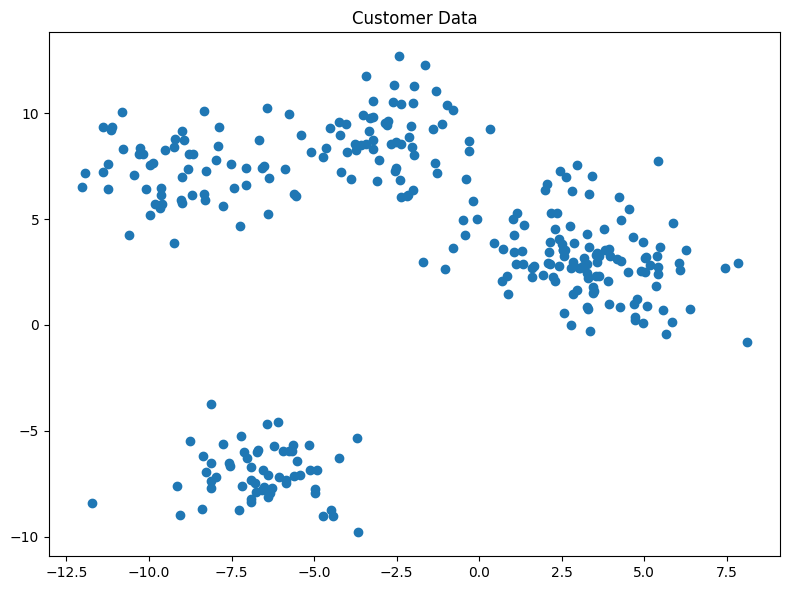

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income'],df['Spending Score']
)

plt.title("Customer Data")

plt.tight_layout()
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_scaled=scaler.fit_transform(df)


In [5]:
from sklearn.cluster import KMeans

inertias=[]

for k in range(1,11):

    model=KMeans(n_clusters=k,random_state=42)

    model.fit(X_scaled)

    inertias.append(
        model.inertia_
    )

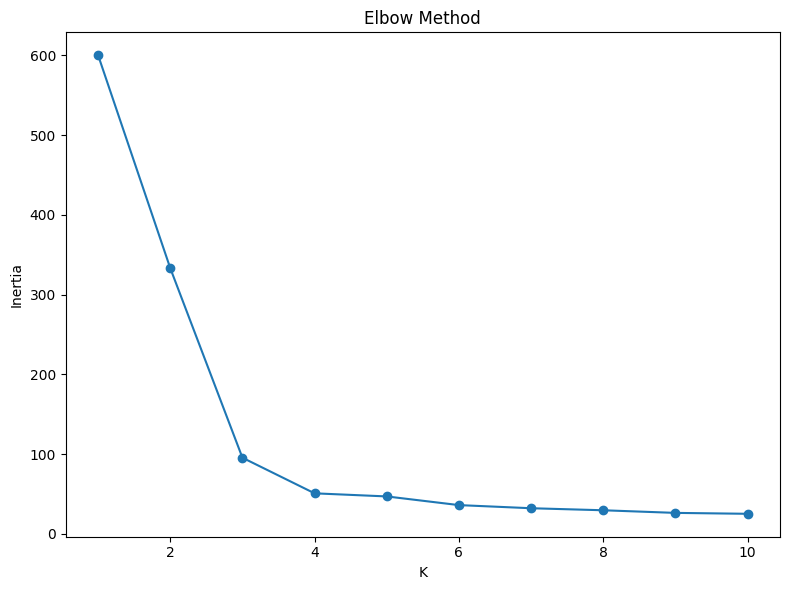

In [6]:
plt.figure(figsize=(8,6))

plt.plot(
    range(1,11),
    inertias,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Inertia")

plt.title("Elbow Method")
plt.tight_layout()

plt.show(
    
)

In [7]:
model=KMeans(
    n_clusters=5,
    random_state=42
)

cluster=model.fit_predict(X_scaled)

df['Cluster']=cluster

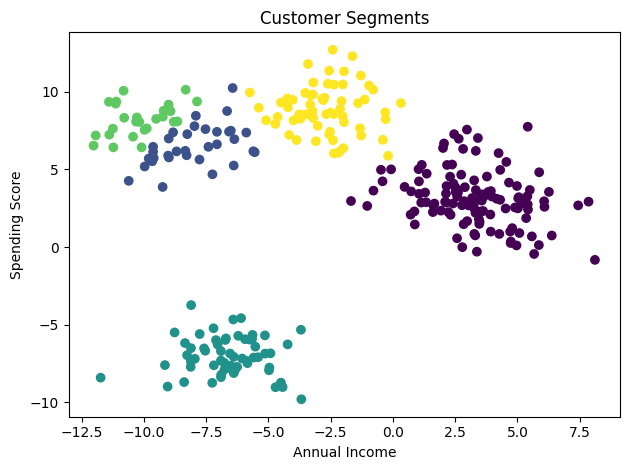

In [8]:
plt.Figure(figsize=(10,6))

plt.scatter(
    df['Annual Income'],
    df['Spending Score'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.title(
    "Customer Segments"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.tight_layout()

plt.show()

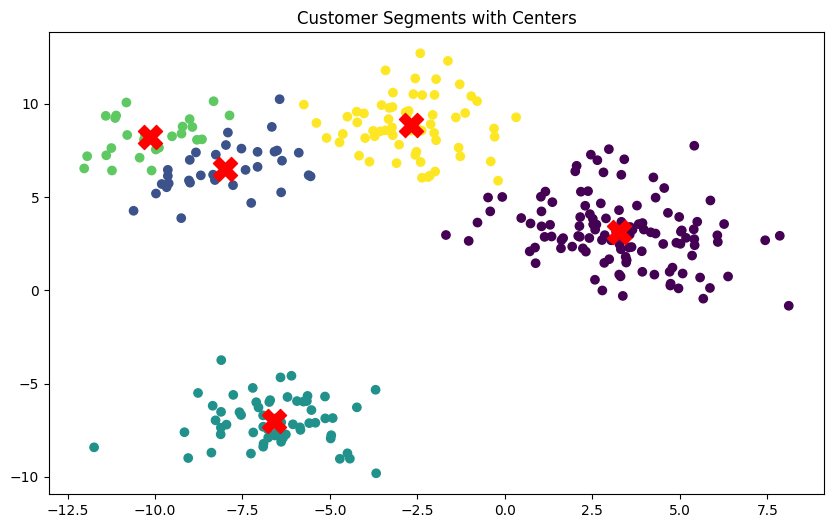

In [9]:
centers=scaler.inverse_transform(
    model.cluster_centers_
)

plt.figure(figsize=(10,6))

plt.scatter(
    df["Annual Income"],
    df['Spending Score'],
    c=df['Cluster'],
    cmap="viridis"
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    color='red',
    marker='X',
    s=300
)

plt.title("Customer Segments with Centers")

plt.show()